<a href="https://colab.research.google.com/github/camilacirne/CRUD-Cursos/blob/main/Intent_Classification_vs_Image_Classification_vs_Ai_as_Judge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Intent Classification vs. Image Classification

Este notebook realiza um estudo comparativo entre abordagens de classificação documental utilizando o dataset RVL-CDIP.

As abordagens avaliadas incluem:

classificação baseada em imagem utilizando CNN;
classificação baseada em intenção utilizando OCR + TF-IDF;
classificação baseada em julgamento semântico utilizando LLMs (AI as a Judge).

As classes selecionadas foram:

*   Email
*   Letter


Foram realizadas 30 simulações para cada abordagem, utilizando teste t pareado para comparação estatística das médias de acurácia.

1. Image Classification (CNN)

Pipeline: imagem → CNN → classe

Objetivo: aprender padrões visuais dos documentos.

2. Intent Classification

Pipeline: imagem → OCR → TF-IDF → Logistic Regression → classe

Objetivo: classificar documentos a partir do conteúdo textual extraído.

3. AI as a Judge

Pipeline: imagem → OCR → Gemini → classe

Objetivo:utilizar um Large Language Model para interpretar semanticamente o conteúdo textual do documento e decidir sua categoria.

Configuração do Ambiente e Download do Dataset

In [15]:
!pip install -q kagglehub

Dataset Acquisition

In [16]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pdavpoojan/the-rvlcdip-dataset-test")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'the-rvlcdip-dataset-test' dataset.
Path to dataset files: /kaggle/input/the-rvlcdip-dataset-test


#Image Classification

CNN Image Preparation

In [17]:
from PIL import Image
import numpy as np

def load_image_cnn(path):
    img = Image.open(path).convert("L")  # grayscale
    img = img.resize((128, 128))

    img = np.array(img) / 255.0  # normalization

    return img.reshape(128, 128, 1)

Seleção das Classes e Rotulação Binária

In [18]:
import os
import random
import pandas as pd

random.seed(42)

base_dir = os.path.join(path, "test")

classes = ["email", "letter"]
samples_per_class = 300

data = []

for label, class_name in enumerate(classes):
    class_dir = os.path.join(base_dir, class_name)

    files = os.listdir(class_dir)
    files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff"))
    ]

    selected_files = random.sample(files, samples_per_class)

    for file in selected_files:
        data.append({
            "image_path": os.path.join(class_dir, file),
            "label": label,
            "class_name": class_name
        })

df = pd.DataFrame(data)

print(df.head())
print(df["class_name"].value_counts())

                                          image_path  label class_name
0  /kaggle/input/the-rvlcdip-dataset-test/test/em...      0      email
1  /kaggle/input/the-rvlcdip-dataset-test/test/em...      0      email
2  /kaggle/input/the-rvlcdip-dataset-test/test/em...      0      email
3  /kaggle/input/the-rvlcdip-dataset-test/test/em...      0      email
4  /kaggle/input/the-rvlcdip-dataset-test/test/em...      0      email
class_name
email     300
letter    300
Name: count, dtype: int64


Image Tensor Construction for CNN

In [19]:
X_cnn = []
y_cnn = []

for _, row in df.iterrows():
    X_cnn.append(load_image_cnn(row["image_path"]))
    y_cnn.append(row["label"])

X_cnn = np.array(X_cnn)
y_cnn = np.array(y_cnn)

print(X_cnn.shape, y_cnn.shape)

(600, 128, 128, 1) (600,)


Criar arquitetura da CNN

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import numpy as np

def create_cnn_model():

    model = models.Sequential([

        tf.keras.Input(shape=(128, 128, 1)),

        layers.Conv2D(
            32,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
            64,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
            128,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),

        layers.Dropout(0.3),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

Rodar 30 simulações

In [22]:
acc_image_cnn = []

for i in range(30):
    print(f"Running CNN simulation {i + 1}/30")

    X_train, X_test, y_train, y_test = train_test_split(
        X_cnn, y_cnn, test_size=0.3, random_state=i, stratify=y_cnn
    )

    tf.keras.backend.clear_session()
    model = create_cnn_model()

    model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    acc_image_cnn.append(acc)

    print(f"Accuracy: {acc:.4f}")

print("CNN Image Classification Mean Accuracy:", np.mean(acc_image_cnn))

Running CNN simulation 1/30
Accuracy: 0.8778
Running CNN simulation 2/30
Accuracy: 0.8833
Running CNN simulation 3/30
Accuracy: 0.8611
Running CNN simulation 4/30
Accuracy: 0.9000
Running CNN simulation 5/30
Accuracy: 0.8500
Running CNN simulation 6/30
Accuracy: 0.8889
Running CNN simulation 7/30
Accuracy: 0.8278
Running CNN simulation 8/30
Accuracy: 0.8778
Running CNN simulation 9/30
Accuracy: 0.8500
Running CNN simulation 10/30
Accuracy: 0.8833
Running CNN simulation 11/30
Accuracy: 0.8889
Running CNN simulation 12/30
Accuracy: 0.8667
Running CNN simulation 13/30
Accuracy: 0.9167
Running CNN simulation 14/30
Accuracy: 0.8556
Running CNN simulation 15/30
Accuracy: 0.8778
Running CNN simulation 16/30
Accuracy: 0.8833
Running CNN simulation 17/30
Accuracy: 0.8611
Running CNN simulation 18/30
Accuracy: 0.8833
Running CNN simulation 19/30
Accuracy: 0.8667
Running CNN simulation 20/30
Accuracy: 0.7667
Running CNN simulation 21/30
Accuracy: 0.9000
Running CNN simulation 22/30
Accuracy: 0.85

#Intent Classification

OCR Setup for Intent Classification

In [23]:
!apt-get install -y tesseract-ocr
!pip install -q pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


OCR Text Extraction

In [24]:
import pytesseract
from PIL import Image

def extract_text(image_path):
    img = Image.open(image_path)
    text = pytesseract.image_to_string(img)
    return text

OCR Dataset Generation/ Text Corpus Construction from OCR

In [26]:
df_ocr = df.sample(200, random_state=42).copy()

In [27]:
texts = []

for i, row in df_ocr.iterrows():

    if i % 20 == 0:
        print(f"Processing OCR {i}/{len(df_ocr)}")

    text = extract_text(row["image_path"])

    texts.append(text)

df_ocr["text"] = texts

print(df_ocr[["class_name", "text"]].head())

Processing OCR 60/200
Processing OCR 300/200
Processing OCR 280/200
Processing OCR 140/200
Processing OCR 340/200
Processing OCR 0/200
Processing OCR 440/200
Processing OCR 320/200
Processing OCR 360/200
Processing OCR 400/200
Processing OCR 380/200
Processing OCR 480/200
    class_name                                               text
110      email   \n\nProposal: Pilferage Study\n\nBackgroun\n\...
419     letter   \n\nTHE TOBACCO INSTITUTE\n\n1875 1 STREET. N...
565     letter    \n\nRb. Requolde\n\nTobacco Company\nTED THO...
77       email     \n \n   \n\n \n\nFrom: Ittermann, Patti F.\...
181      email  2077549167\n\nDunham, John\n‘Monday, August 16...


Intent Classification Training and Evaluation

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

X_text_raw = df_ocr["text"].fillna("")
y_text = df_ocr["label"].values

acc_intent = []

for i in range(30):
    X_train_text, X_test_text, y_train, y_test = train_test_split(
        X_text_raw,
        y_text,
        test_size=0.3,
        random_state=i,
        stratify=y_text
    )

    vectorizer = TfidfVectorizer(
        max_features=1000,
        stop_words="english"
    )

    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    acc_intent.append(acc)

print(acc_intent)
print("Média Intent Classification:", np.mean(acc_intent))

[0.8666666666666667, 0.9, 0.8666666666666667, 0.9166666666666666, 0.8666666666666667, 0.7666666666666667, 0.95, 0.85, 0.85, 0.8833333333333333, 0.8666666666666667, 0.8666666666666667, 0.8666666666666667, 0.9166666666666666, 0.9, 0.9, 0.8833333333333333, 0.8666666666666667, 0.8333333333333334, 0.8833333333333333, 0.8666666666666667, 0.8833333333333333, 0.8833333333333333, 0.9, 0.8833333333333333, 0.85, 0.9166666666666666, 0.8166666666666667, 0.95, 0.8833333333333333]
Média Intent Classification: 0.8777777777777778


Statistical Comparison Between Approaches

In [29]:
from scipy.stats import ttest_rel
import numpy as np

t_stat, p_value = ttest_rel(
    acc_image_cnn,
    acc_intent
)

print(
    "CNN Image Classification Mean Accuracy:",
    np.mean(acc_image_cnn)
)

print(
    "Intent Classification Mean Accuracy:",
    np.mean(acc_intent)
)

print("p-value:", p_value)

CNN Image Classification Mean Accuracy: 0.8711111068725585
Intent Classification Mean Accuracy: 0.8777777777777778
p-value: 0.4451496588418392


Accuracy Comparison Between Approaches

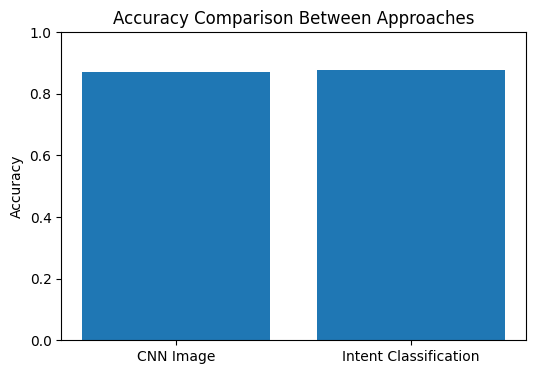

In [30]:
import matplotlib.pyplot as plt

methods = [
    "CNN Image",
    "Intent Classification"
]

means = [
    np.mean(acc_image_cnn),
    np.mean(acc_intent)
]

plt.figure(figsize=(6,4))

plt.bar(methods, means)

plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.title("Accuracy Comparison Between Approaches")

plt.show()

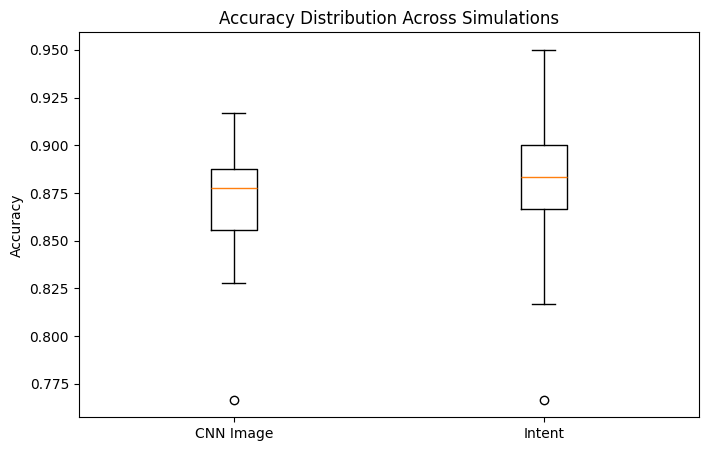

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(
    [acc_image_cnn, acc_intent],
    tick_labels=[
        "CNN Image",
        "Intent"
    ]
)

plt.ylabel("Accuracy")

plt.title(
    "Accuracy Distribution Across Simulations"
)

plt.show()

Desvio Padrão

In [33]:
print("CNN std:", np.std(acc_image_cnn))
print("Intent std:", np.std(acc_intent))

CNN std: 0.02837868554319785
Intent std: 0.03583225665910465


Os resultados indicam que a abordagem baseada em CNN apresentou desempenho semelhante à Intent Classification. Embora a Intent Classification tenha obtido média ligeiramente superior (≈ 0.878) em relação à CNN (≈ 0.871), o teste t pareado resultou em p-value ≈ 0.445, indicando ausência de diferença estatisticamente significativa entre as abordagens.

Matriz de Confusão da CNN

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 253ms/step


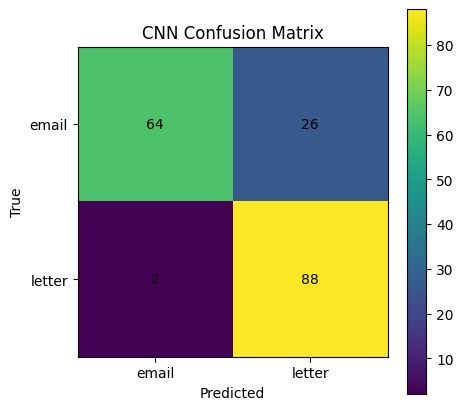

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn,
    y_cnn,
    test_size=0.3,
    random_state=42,
    stratify=y_cnn
)

cnn_model = create_cnn_model()

cnn_model.fit(
    X_train_cnn,
    y_train_cnn,
    epochs=5,
    batch_size=32,
    verbose=0
)

cnn_preds = (
    cnn_model.predict(X_test_cnn) > 0.5
).astype(int)

cm = confusion_matrix(y_test_cnn, cnn_preds)

plt.figure(figsize=(5, 5))
plt.imshow(cm)
plt.title("CNN Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["email", "letter"])
plt.yticks([0, 1], ["email", "letter"])

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

#AI as a Judge Classification

Instalar SDK do Gemini

In [35]:
!pip install -q "google-genai>=1.66.0,<2.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.7/793.7 kB 16.1 MB/s eta 0:00:00


Configurar API Key pelo Colab Secrets



In [65]:
from google import genai
from google.colab import userdata
import time
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

api_key = userdata.get("GEMINI_API_KEY")

if api_key is None:
    raise ValueError("GEMINI_API_KEY não encontrada nos Colab Secrets.")

client = genai.Client(api_key=api_key)

SecretNotFoundError: Secret GEMINI_API_KEY does not exist.

Criar função AI Judge

In [66]:
def ai_judge_classify(text):
    prompt = f"""
You are a document classification judge.

Classify the document into exactly one of these classes:
- email
- letter

Return only one word: email or letter.

OCR text:
{text[:2000]}
"""

    try:
        response = client.models.generate_content(
            model="models/gemini-2.0-flash-lite",
            contents=prompt
        )

        answer = response.text.strip().lower()

        if "email" in answer:
            return 0
        elif "letter" in answer:
            return 1
        else:
            return -1

    except Exception as e:
        print("AI Judge error:", e)
        return -1

Rodar uma primeira avaliação pequena

In [68]:
df_judge = df_ocr.sample(5, random_state=42).copy()

ai_preds = []

for text in df_judge["text"]:
    pred = ai_judge_classify(text)
    ai_preds.append(pred)
    time.sleep(2)

df_judge["ai_pred"] = ai_preds

valid_df = df_judge[df_judge["ai_pred"] != -1]

if len(valid_df) > 0:
    ai_judge_acc = accuracy_score(valid_df["label"], valid_df["ai_pred"])
    print("AI as a Judge Accuracy:", ai_judge_acc)
    print(valid_df[["class_name", "ai_pred"]].head())
else:
    print("No valid AI Judge predictions were generated.")

AI Judge error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash-lite\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash-lite\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash-lite\nPlease retry in 1.092456952s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {

KeyboardInterrupt: 

Matriz de Confusão

In [69]:
if len(valid_df) > 0:
    cm = confusion_matrix(valid_df["label"], valid_df["ai_pred"])

    plt.figure(figsize=(5, 5))
    plt.imshow(cm)
    plt.title("AI as a Judge Confusion Matrix")
    plt.colorbar()

    plt.xticks([0, 1], ["email", "letter"])
    plt.yticks([0, 1], ["email", "letter"])

    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.show()
else:
    print("Confusion matrix was not generated because there are no valid predictions.")

NameError: name 'valid_df' is not defined

30 simulações

In [ ]:
acc_ai_judge = []

for i in range(30):
    print(f"Running AI Judge simulation {i + 1}/30")

    df_judge = df_ocr.sample(20, random_state=i).copy()

    ai_preds = []

    for text in df_judge["text"]:
        pred = ai_judge_classify(text)
        ai_preds.append(pred)
        time.sleep(2)

    df_judge["ai_pred"] = ai_preds
    valid_df = df_judge[df_judge["ai_pred"] != -1]

    if len(valid_df) > 0:
        acc = accuracy_score(valid_df["label"], valid_df["ai_pred"])
        acc_ai_judge.append(acc)
        print("Accuracy:", acc)
    else:
        print("No valid predictions in this simulation.")

if len(acc_ai_judge) > 0:
    print("AI Judge Mean Accuracy:", np.mean(acc_ai_judge))
else:
    print("AI Judge could not be evaluated due to API limitations.")